Figure S11: pcQTL discoveries by PC order. A The fraction of PC phenotypes across tissues with at least one significant QTL split into the primary (first) PC, the last PC, and all other PCs (middle). p-values are from a independent t-test. B Distribution of the maximum PPH4 colocalization probability for each pcQTL credible set with any cluster eQTL credible set. Dotted line PPH4=0.75. C The fraction of PC phenotypes across tissues with at least one novel significant QTL split into the primary (first) PC, the last PC, and all other PCs (middle). P-values are from an independent t-test.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from statannotations.Annotator import Annotator

from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 

%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

In [7]:
susie_annotated = load_across_tissues(config, load_susie_annotated)
pcs = load_across_tissues(config, load_pc)

pcs['phenotype_id'] = pcs['gene_id']
pcs['cluster_id'] = pcs['phenotype_id'].str.split('_pc').str[0]
pcs['num_genes'] = pcs['cluster_id'].str.split('_').apply(len)
pcs['pc_num'] = pcs['phenotype_id'].str.split('_pc').str[1].astype(int)
pcs['pc_order'] = np.where(pcs['pc_num']==1, 'first', np.where(pcs['pc_num']==pcs['num_genes'], 'last', 'middle'))

susie_annotated['phenotype_id_tissue'] = susie_annotated['phenotype_id'] + '-' + susie_annotated['tissue_id']
pcs['phenotype_id_tissue'] = pcs['phenotype_id'] + '-' + pcs['tissue_id']
pcs['has_cs'] = pcs['phenotype_id_tissue'].isin(susie_annotated['phenotype_id_tissue'])

# fraction phenotypes of each type that have a credible set
pc_cs_by_order = pcs.groupby(['tissue_id', 'pc_order']).agg({'has_cs':'mean'}).reset_index()

# pairwise coloc
pair_coloc = load_across_tissues(config, load_pairwise_coloc)
pair_coloc['qtl1_id_tissue'] = pair_coloc['qtl1_id'] + '-' + pair_coloc['tissue_id']
pair_coloc['qtl2_id_tissue'] = pair_coloc['qtl2_id'] + '-' + pair_coloc['tissue_id']

# signal groups
underlying_signals = load_across_tissues(config, load_qtl_signal_groups)
underlying_signals['cs_id'] = underlying_signals['signal_id'].str.split('-')
underlying_signals_explode = underlying_signals.explode('cs_id')
underlying_signals_explode['phenotype_id_tissue'] = underlying_signals_explode['cs_id'].str.split('_cs').str[0] + '-' + underlying_signals['tissue_id']
# the ones with no e colocs
pcs['has_novel_cs'] = pcs['phenotype_id_tissue'].isin(underlying_signals_explode[underlying_signals_explode['num_e_coloc']==0]['phenotype_id_tissue'])
novel_cs_by_order = pcs.groupby(['tissue_id', 'pc_order']).agg({'has_novel_cs':'mean'}).reset_index()

/local/scratch/klawren/slrmtmp.49273977/ipykernel_35309/3144396355.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcs['phenotype_id'] = pcs['gene_id']
/local/scratch/klawren/slrmtmp.49273977/ipykernel_35309/3144396355.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcs['cluster_id'] = pcs['phenotype_id'].str.split('_pc').str[0]
/local/scratch/klawren/slrmtmp.49273977/ipykernel_35309/3144396355.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

/local/scratch/klawren/slrmtmp.49273977/ipykernel_35309/1632070060.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(pc_cs_by_order, x='pc_order', y='has_cs', ax=ax_a,
/local/scratch/klawren/slrmtmp.49273977/ipykernel_35309/1632070060.py:6: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(pc_cs_by_order, x='pc_order', y='has_cs', ax=ax_a,


first vs. middle: t-test independent samples, P_val:2.673e-05 t=5.175e+00
middle vs. last: t-test independent samples, P_val:2.325e-01 t=-1.225e+00
first vs. last: t-test independent samples, P_val:2.453e-05 t=5.209e+00


/local/scratch/klawren/slrmtmp.49273977/ipykernel_35309/1632070060.py:45: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ].groupby('qtl2_id_tissue').agg({'PP.H4.abf':max}).reset_index()
/local/scratch/klawren/slrmtmp.49273977/ipykernel_35309/1632070060.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(novel_cs_by_order, x='pc_order', y='has_novel_cs', ax=ax_c,
/local/scratch/klawren/slrmtmp.49273977/ipykernel_35309/1632070060.py:57: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(novel_cs_by_order, x='pc_order', y='has_novel_cs', ax=ax_c,


first vs. middle: t-test independent samples, P_val:9.304e-05 t=-4.683e+00
middle vs. last: t-test independent samples, P_val:4.847e-01 t=-7.097e-01
first vs. last: t-test independent samples, P_val:2.584e-08 t=-8.091e+00


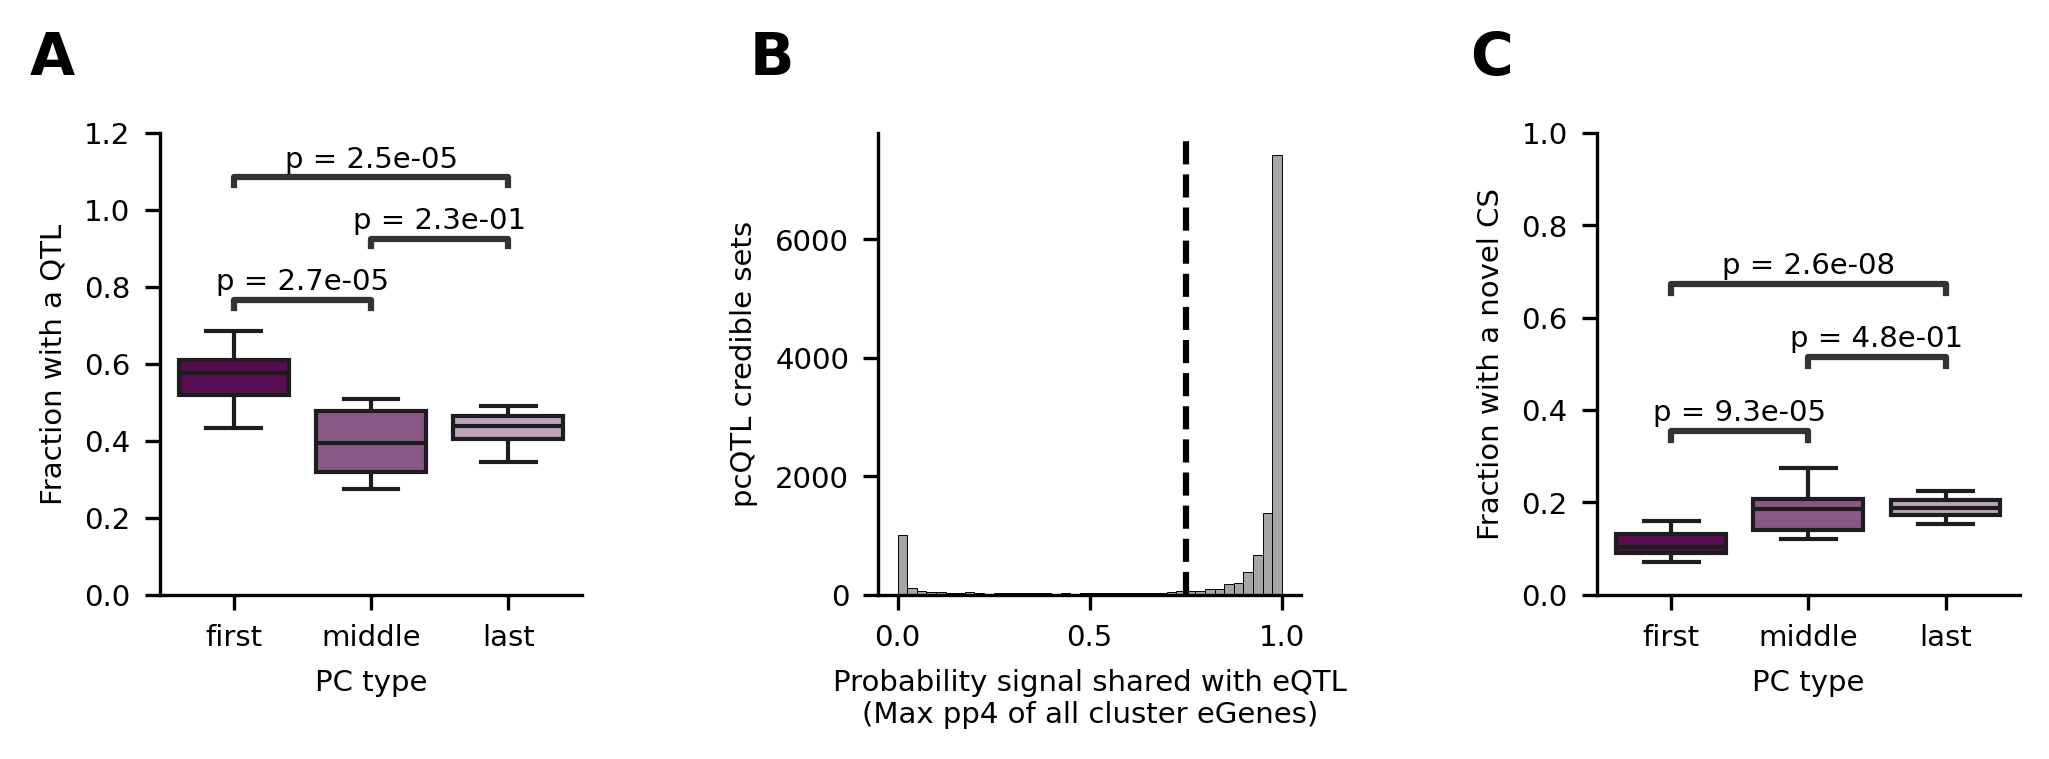

In [35]:
# Three-panel (A,B,C) plot, with stats annotator on A and C

fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(8,2), gridspec_kw={'wspace':0.7}, dpi=300)

# --- Panel A ---
sns.boxplot(pc_cs_by_order, x='pc_order', y='has_cs', ax=ax_a,
            palette=sns.color_palette('light:{}_r'.format(qtl_palette['pcQTL only']), n_colors=4),
            order=['first', 'middle', 'last'])
ax_a.set_ylim([0,1])

# Statistical annotation with Annotator from statannotations
pairs = [
    ("first", "middle"),
    ("first", "last"),
    ("middle", "last"),
]

annotator_a = Annotator(
    ax_a,
    pairs,
    data=pc_cs_by_order,
    x='pc_order', y='has_cs',
    order=['first', 'middle', 'last']
)
annotator_a.configure(
    test='t-test_ind',
    text_format='full',
    pvalue_format_string='{:.1e}',
    loc='inside',
    show_test_name=False,
    verbose=1
)
annotator_a.apply_and_annotate()

ax_a.spines[['top', 'right']].set_visible(False)
ax_a.set_xlabel('PC type')
ax_a.set_ylabel('Fraction with a QTL')
ax_a.text(-.2, 1.1, 'A', transform=ax_a.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# --- Panel B ---
pc_coloc_with_any_e = pair_coloc[
    (pair_coloc['qtl1_id_tissue'].str.contains('_e_')) &
    (pair_coloc['qtl2_id_tissue'].str.contains('_pc'))
].groupby('qtl2_id_tissue').agg({'PP.H4.abf':max}).reset_index()

sns.histplot(pc_coloc_with_any_e, x='PP.H4.abf', multiple='dodge', bins=40, ax=ax_b,
             common_norm=False, color='grey', alpha=.7)
ax_b.spines[['top', 'right']].set_visible(False)
ax_b.set_ylabel('pcQTL credible sets')
ax_b.set_xlabel('Probability signal shared with eQTL\n(Max pp4 of all cluster eGenes)')
ax_b.axvline(.75, color='k', ls='--')
ax_b.text(-.2, 1.1, 'B', transform=ax_b.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# --- Panel C ---
sns.boxplot(novel_cs_by_order, x='pc_order', y='has_novel_cs', ax=ax_c, 
            palette=sns.color_palette('light:{}_r'.format(qtl_palette['pcQTL only']), n_colors=4), 
            order=['first', 'middle', 'last'])
ax_c.set_ylim([0,1])

# Statistical annotation with Annotator from statannotations
annotator_c = Annotator(
    ax_c,
    pairs,
    data=novel_cs_by_order,
    x='pc_order', y='has_novel_cs',
    order=['first', 'middle', 'last']
)
annotator_c.configure(
    test='t-test_ind',
    text_format='full',
    pvalue_format_string='{:.1e}',
    loc='inside',
    show_test_name=False,
    verbose=1
)
annotator_c.apply_and_annotate()

ax_c.spines[['top', 'right']].set_visible(False)
ax_c.set_xlabel('PC type')
ax_c.set_ylabel('Fraction with a novel CS')
ax_c.text(-.2, 1.1, 'C', transform=ax_c.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s11.pdf", transparent=True, bbox_inches='tight')
plt.show()
